<a href="https://colab.research.google.com/github/241cd008-lab/Healthmate-BMI-Analyzerr/blob/main/ML_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Employee_Salary_Dataset_50Rows.xlsx to Employee_Salary_Dataset_50Rows.xlsx


In [4]:
df = pd.read_excel("Employee_Salary_Dataset_50Rows.xlsx")

df.head()

,EmployeeID,Age,Gender,Education,YearsExperience,City,Department,PerformanceScore,WorkingHoursPerWeek,ProjectsCompleted,TrainingHours,Salary
0,E001,22,Female,Bachelor,1,Chennai,IT,78,40,2,15,35000
1,E002,23,Male,Bachelor,2,Bangalore,HR,80,41,3,16,39000
2,E003,24,Female,Master,2,Hyderabad,Finance,82,42,3,18,42000
3,E004,25,Male,Bachelor,3,Pune,Marketing,84,43,4,19,47000
4,E005,26,Female,Master,4,Chennai,IT,86,44,5,20,52000


In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Shape:")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   EmployeeID           50 non-null     object
 1   Age                  50 non-null     int64 
 2   Gender               50 non-null     object
 3   Education            50 non-null     object
 4   YearsExperience      50 non-null     int64 
 5   City                 50 non-null     object
 6   Department           50 non-null     object
 7   PerformanceScore     50 non-null     int64 
 8   WorkingHoursPerWeek  50 non-null     int64 
 9   ProjectsCompleted    50 non-null     int64 
 10  TrainingHours        50 non-null     int64 
 11  Salary               50 non-null     int64 
dtypes: int64(7), object(5)
memory usage: 4.8+ KB
None

Missing Values:
EmployeeID             0
Age                    0
Gender                 0
Education              0
YearsExperience        0
City          

In [6]:
encoder = LabelEncoder()

categorical_columns = ['Gender','Education','City','Department']

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,EmployeeID,Age,Gender,Education,YearsExperience,City,Department,PerformanceScore,WorkingHoursPerWeek,ProjectsCompleted,TrainingHours,Salary
0,E001,22,0,0,1,1,2,78,40,2,15,35000
1,E002,23,1,0,2,0,1,80,41,3,16,39000
2,E003,24,0,1,2,2,0,82,42,3,18,42000
3,E004,25,1,0,3,3,3,84,43,4,19,47000
4,E005,26,0,1,4,1,2,86,44,5,20,52000


In [7]:
X = df.drop(['EmployeeID','Salary'], axis=1)

y = df['Salary']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

print("Predicted Salaries")
print(y_pred)

Predicted Salaries
[ 97816.76825604 140334.78607674  45840.33032551 104470.98675264
 118382.83271698 133217.70540523 103763.51050462  93943.30371008
  69149.81728988 134103.72421089]


In [11]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 1988.251969895819
Mean Squared Error : 8295845.59151983
Root Mean Squared Error : 2880.2509598157985
R2 Score : 0.9897455555111003


In [12]:
result = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred.astype(int)
})

print(result)

    Actual Salary  Predicted Salary
13          97000             97816
39         142000            140334
30          46000             45840
45         105000            104470
17         117000            118382
48         138000            133217
26         105000            103763
25          95000             93943
32          68000             69149
19         127000            134103


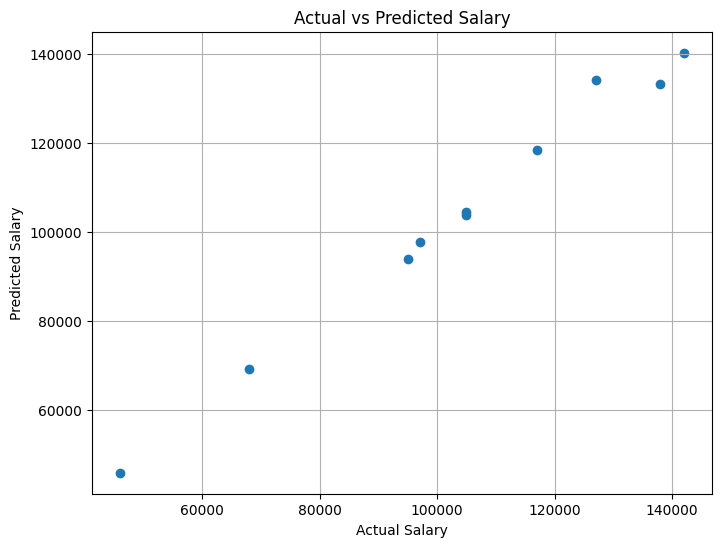

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.grid(True)

plt.show()

In [14]:
new_employee = [[30,1,1,8,1,2,90,45,8,25]]

prediction = model.predict(new_employee)

print("Predicted Salary =", prediction[0])

Predicted Salary = 76525.9718334243


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
